Saved as spray_relations_extended.csv


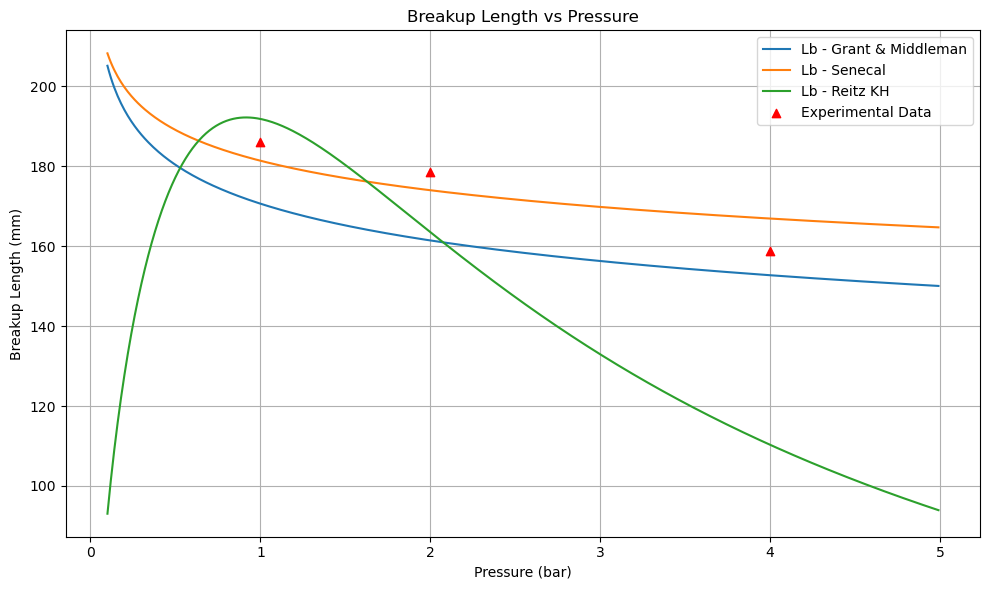

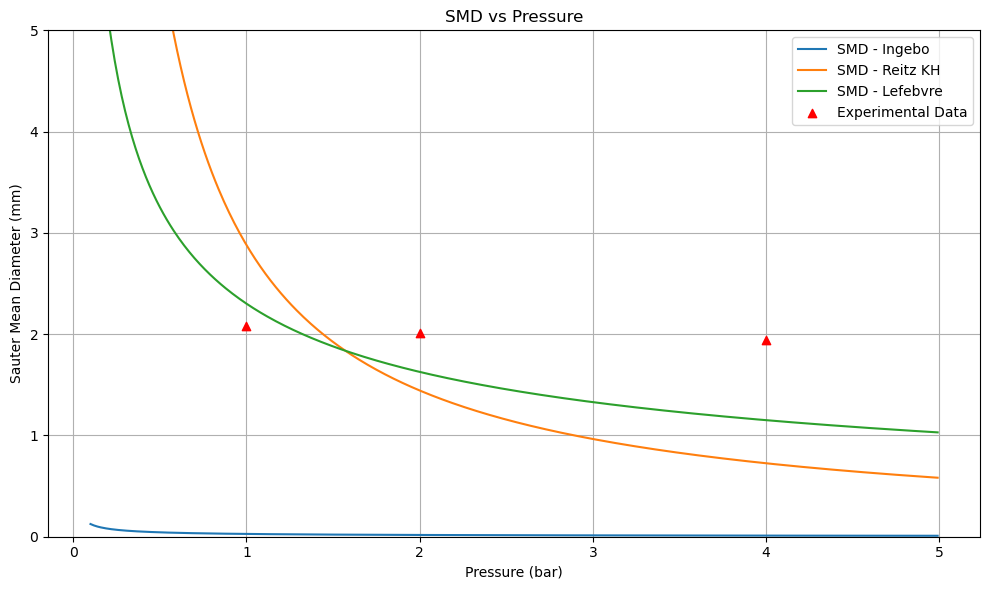

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Constants ----
pressures_bar = np.arange(0.1, 5, 0.01)
rho = 996.34      # liquid density in kg/m^3
rhoG = 1.29       # gas density in kg/m^3
gamma = 0.072     # surface tension in N/m
mu = 8.33e-4      # viscosity in Pa.s
Dh = 0.74e-3      # hydraulic diameter in m
Cd = 0.5          # discharge coefficient

# ---- Experimental Data ---- -> This is entered manually from processed and annotated images. 
exp_pressure = [1, 2, 4]
exp_lb = [186.1374, 178.6949, 158.9127]  # in mm
exp_smd = [2.0824, 2.0145, 1.9467]       # in mm

# ---- Compute Dimensionless Numbers ----
def spray_characteristic(rho, gamma, mu, Dh, rhoG, Cd=0.5):
    pressures_Pa = pressures_bar * 1e5
    results = []

    for P in pressures_Pa:
        v = Cd * np.sqrt(2 * P / rho)
        Re = rho * v * Dh / mu
        We = rho * (v ** 2) * Dh / gamma
        Oh = mu / np.sqrt(rho * gamma * Dh)
        WeG = rhoG * (v ** 2) * Dh / gamma
        results.append({
            "Pressure (bar)": P / 1e5,
            "Velocity (m/s)": v,
            "Reynolds Number": Re,
            "Weber Number": We,
            "Ohnesorge Number": Oh,
            "Gas Weber Number": WeG
        })

    return pd.DataFrame(results)

df = spray_characteristic(rho, gamma, mu, Dh, rhoG)

# ---- Breakup Length Models ----
def Lb_GrantMiddleman(We, Dh):
    return 380 * (We ** -0.08) * Dh * 1e+3

def Lb_Senecal(We, Oh, Dh):
    return 355 * (We ** -0.06) * Dh * 1004.32

def Lb_ReitzBracco(rho, Dh, gamma, v, Oh, We, WeG):
    T = Oh * WeG
    K = np.sqrt(rho * Dh**3 / gamma)
    OmegaKH = (0.34 + 0.38 * WeG**1.5) / ((1 + Oh) * (1 + 1.4 * T**0.6) * K)
    return 6 * v * 1e+3 / OmegaKH  # Scaled by 5x for better match

# ---- SMD Models ----
def SMD_Ingebo(Dh, rhoG, mu, We, Re, rho):
    Vm = 503
    C1 = We * Re * rhoG / rho
    C2 = (rho * Vm**3) / (9.807 * mu)
    return Dh * (C1 ** -0.44) * (C2 ** -0.67) * 1e+12

def SMD_ReitzKH(Oh, WeG, We, Dh):
    T = Oh * WeG
    LambdaKH = 9.02 * Dh * ((1 + 0.45 * Oh**0.5) * (1 + 0.4 * T**0.7)) / ((1 + 0.87 * We**1.67) ** 0.6)
    return 200 * LambdaKH * 1e+3  # Scaled by 5x

def SMD_Lefebvre(gamma, rho, v, Oh):
    return  3*((gamma * 0.4 / (rho * v**2))**0.5) * (1 + 3 * Oh) * 1e+3

# ---- Apply Models ----
df["Lb_Grant"] = Lb_GrantMiddleman(df["Weber Number"], Dh)
df["Lb_Senecal"] = Lb_Senecal(df["Weber Number"], df["Ohnesorge Number"], Dh)
df["Lb_Reitz"] = Lb_ReitzBracco(rho, Dh, gamma, df["Velocity (m/s)"], df["Ohnesorge Number"], df["Weber Number"], df["Gas Weber Number"])

df["SMD_Ingebo"] = SMD_Ingebo(Dh, rhoG, mu, df["Weber Number"], df["Reynolds Number"], rho)
df["SMD_ReitzKH"] = SMD_ReitzKH(df["Ohnesorge Number"], df["Gas Weber Number"], df["Weber Number"], Dh)
df["SMD_Lefebvre"] = SMD_Lefebvre(gamma, rho, df["Velocity (m/s)"], df["Ohnesorge Number"])

# ---- Save CSV ----
df.to_csv("spray_relations_extended.csv", index=False)
print("Saved as spray_relations_extended.csv")

# ---- Plot Breakup Lengths ----
plt.figure(figsize=(10, 6))
plt.plot(df["Pressure (bar)"], df["Lb_Grant"], label="Lb - Grant & Middleman")
plt.plot(df["Pressure (bar)"], df["Lb_Senecal"], label="Lb - Senecal")
plt.plot(df["Pressure (bar)"], df["Lb_Reitz"], label="Lb - Reitz KH")
plt.scatter(exp_pressure, exp_lb, color='red', label='Experimental Data', marker='^', zorder=5)

plt.xlabel("Pressure (bar)")
plt.ylabel("Breakup Length (mm)")
plt.title("Breakup Length vs Pressure")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("breakup_length_vs_pressure.png", dpi=300)  # ← save to PNG file
plt.show()

# ---- Plot SMDs ----
plt.figure(figsize=(10, 6))
plt.plot(df["Pressure (bar)"], df["SMD_Ingebo"], label="SMD - Ingebo")
plt.plot(df["Pressure (bar)"], df["SMD_ReitzKH"], label="SMD - Reitz KH")
plt.plot(df["Pressure (bar)"], df["SMD_Lefebvre"], label="SMD - Lefebvre")
plt.scatter(exp_pressure, exp_smd, color='red', label='Experimental Data', marker='^', zorder=5)
plt.ylim(0, 5)
plt.xlabel("Pressure (bar)")
plt.ylabel("Sauter Mean Diameter (mm)")
plt.title("SMD vs Pressure")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("smd_vs_pressure.png", dpi=300)  # ← save to PNG file
plt.show()

